In [15]:
# --- CELL 1: imports & paths ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from pycirclize import Circos

CSV_IN  = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/master_df_interactions_all.csv")
OUT_DIR = Path("/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [16]:
# --- CELL 2: load csv ---
# Tries to auto-detect delimiter; if you KNOW it is tab, set sep="\t".
df = pd.read_csv(CSV_IN, sep=None, engine="python")

expected = {"interaction","ligand","receptor","ligand_means","ligand_props",
            "receptor_means","receptor_props","morans","morans_pvals",
            "mean","std","condition","mouse"}
missing = expected - set(df.columns)
assert not missing, f"Missing columns: {missing}"

# coerce numerics (handles '0' and scientific notation safely)
for col in ["ligand_means","receptor_means","morans","morans_pvals"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# drop rows lacking the essentials
df = df.dropna(subset=["ligand","receptor","morans","ligand_means","receptor_means"]).copy()


In [44]:
# --- CELL 3: analysis knobs ---
# Choose a condition or leave as None to pool all
SELECT_COND   = None            # e.g., "RTCyPSCA" or "CyPSCA"
SELECT_MOUSE  = None            # e.g., "RTCyPSCA_2_4" or None

# Selection logic
USE_ABS_MORANS_FOR_SELECTION = True
TOP_N        = 20               # how many interactions to draw
FILTER_BY_Q  = False            # set True to filter by BH-FDR before ranking
ALPHA_Q      = 0.05

# Width metric for chord thickness
WIDTH_METRIC = "geom_mean"      # options: "geom_mean", "sum_means", "ligand", "receptor"
UNITS_MIN, UNITS_MAX = 0.6, 6.0 # min/max span units per link (controls thickness)

# Visual
CIRCOS_SPACE_DEG = 8            # gap between sectors
LABEL_SIZE       = 8
LABEL_R          = 118
TITLE            = "LIANA interactions: width=√(ligand·receptor), color=Moran's I"


In [45]:
# --- CELL 4: subset & aggregate ---
sub = df.copy()
if SELECT_COND is not None:
    sub = sub.query("condition == @SELECT_COND").copy()
if SELECT_MOUSE is not None:
    sub = sub.query("mouse == @SELECT_MOUSE").copy()

# Aggregate potential duplicate rows per interaction (e.g., across mice) by mean
group_cols = ["interaction","ligand","receptor"]
if SELECT_COND is None:
    # keep condition-aware label only if you want; here we pool all conditions by mean
    pass
agg = {
    "ligand_means":"mean",
    "receptor_means":"mean",
    "morans":"mean",
    "morans_pvals":"mean",
}
sub_agg = sub.groupby(group_cols, as_index=False).agg(agg)

# Benjamini–Hochberg q-values (if used)
if FILTER_BY_Q:
    p = sub_agg["morans_pvals"].fillna(1.0).to_numpy()
    m = len(p)
    order = np.argsort(p)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, m+1)
    q = p * m / ranks
    # monotone
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    q_adj = np.empty_like(q)
    q_adj[order] = q_sorted
    sub_agg["qval"] = q_adj
    sub_agg = sub_agg.query("qval <= @ALPHA_Q").copy()


In [46]:
# --- CELL 5: selection, widths, colors ---
# Selection score
sel_score = sub_agg["morans"].abs() if USE_ABS_MORANS_FOR_SELECTION else sub_agg["morans"]
top = sub_agg.assign(sel_score=sel_score).sort_values("sel_score", ascending=False).head(TOP_N).copy()

# Width metric
if WIDTH_METRIC == "geom_mean":
    width_raw = np.sqrt(top["ligand_means"].clip(lower=0) * top["receptor_means"].clip(lower=0))
elif WIDTH_METRIC == "sum_means":
    width_raw = top["ligand_means"].clip(lower=0) + top["receptor_means"].clip(lower=0)
elif WIDTH_METRIC == "ligand":
    width_raw = top["ligand_means"].clip(lower=0)
elif WIDTH_METRIC == "receptor":
    width_raw = top["receptor_means"].clip(lower=0)
else:
    raise ValueError("Unknown WIDTH_METRIC")

# Normalize to span-units used by pyCirclize's link intervals
wmin, wmax = float(width_raw.min()), float(width_raw.max())
if wmax == wmin:
    widths = np.full_like(width_raw, (UNITS_MIN + UNITS_MAX)/2.0, dtype=float)
else:
    widths = np.interp(width_raw, (wmin, wmax), (UNITS_MIN, UNITS_MAX))

top["span_units"] = widths

# Colors by Moran's I (two-slope norm centered at 0)
cmap = cm.get_cmap("coolwarm")
vmin, vmax = float(top["morans"].min()), float(top["morans"].max())
if vmin == vmax:
    norm = mcolors.Normalize(vmin=vmin-1e-6, vmax=vmax+1e-6)
else:
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
top["color_rgba"] = [cmap(norm(v)) for v in top["morans"]]

# Export the exact subset (for record)
cond_tag = SELECT_COND if SELECT_COND is not None else "ALL"
csv_used = OUT_DIR / f"liana_circos_selection_{cond_tag}_top{TOP_N}.csv"
# top.to_csv(csv_used, index=False)
csv_used


/tmp/ipykernel_18535/590556826.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm")


PosixPath('/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/figures/R01_figs/liana_circos_selection_ALL_top20.csv')

In [47]:
# --- CELL 6: sector sizes from link spans ---
lig_genes = top["ligand"].astype(str)
rec_genes = top["receptor"].astype(str)

lig_unique = sorted(lig_genes.unique())
rec_unique = sorted(rec_genes.unique())

# If any symbol appears in both roles, disambiguate labels
overlap = set(lig_unique).intersection(rec_unique)
def make_name(g, side):
    if g in overlap:
        return f"{g} ({side})"
    return g

# Sectors dict must map name -> size (sum of spans incident on that sector)
from collections import defaultdict, OrderedDict
lig_size = defaultdict(float)
rec_size = defaultdict(float)

for (_, row) in top.iterrows():
    lig = make_name(str(row["ligand"]), "L")
    rec = make_name(str(row["receptor"]), "R")
    s = float(row["span_units"])
    lig_size[lig] += s
    rec_size[rec] += s

# Order sectors by total size (largest first) to reduce clutter
lig_order = [k for k,_ in sorted(lig_size.items(), key=lambda kv: kv[1], reverse=True)]
rec_order = [k for k,_ in sorted(rec_size.items(), key=lambda kv: kv[1], reverse=True)]

sectors = OrderedDict()
for name in lig_order:
    sectors[name] = max(lig_size[name], UNITS_MIN)  # guard tiny sizes
for name in rec_order:
    sectors[name] = max(rec_size[name], UNITS_MIN)

len(sectors), next(iter(sectors.items()))


(18, ('Fn1', 21.07455626448122))

In [48]:
# --- CELL 7: initialize circos & labels ---
# --- SAFETY GAP: compute a gap that cannot exceed the circle ---
n_sec = len(sectors)
# theoretical max average gap (one gap per sector; pycirclize makes the last one 0)
max_space = 360.0 / max(1, n_sec)      # deg
# pick the smaller of your request and the safe max (minus a tiny margin), but keep ≥0.5°
SAFE_SPACE_DEG = max(0.5, min(CIRCOS_SPACE_DEG, max_space - 0.5))

print(f"n_sectors={n_sec} | requested space={CIRCOS_SPACE_DEG}° "
      f"| using={SAFE_SPACE_DEG:.2f}° (max ≈ {max_space:.2f}°)")

circos = Circos(sectors, space=SAFE_SPACE_DEG)

# Put simple labels just outside the ring
for sector in circos.sectors:
    label = sector.name.replace(" (L)", "").replace(" (R)", "")
    sector.text(label, r=LABEL_R, size=LABEL_SIZE)


n_sectors=18 | requested space=8° | using=8.00° (max ≈ 20.00°)


In [49]:
# --- CELL 8: plot links ---
# per-sector running offsets so links pack consecutively
offset = {s.name: 0.0 for s in circos.sectors}

for idx, row in top.iterrows():
    lig = make_name(str(row["ligand"]), "L")
    rec = make_name(str(row["receptor"]), "R")
    s   = float(row["span_units"])
    col = row["color_rgba"]

    # take current offset window [pos, pos+s) on each sector
    x0, x1 = offset[lig], offset[lig] + s
    y0, y1 = offset[rec], offset[rec] + s

    circos.link((lig, x0, x1), (rec, y0, y1),
                color=col, ec="none", alpha=0.9, direction=1)  # direction adds subtle arrowhead

    offset[lig] = x1
    offset[rec] = y1


/home/jon/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/jon/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


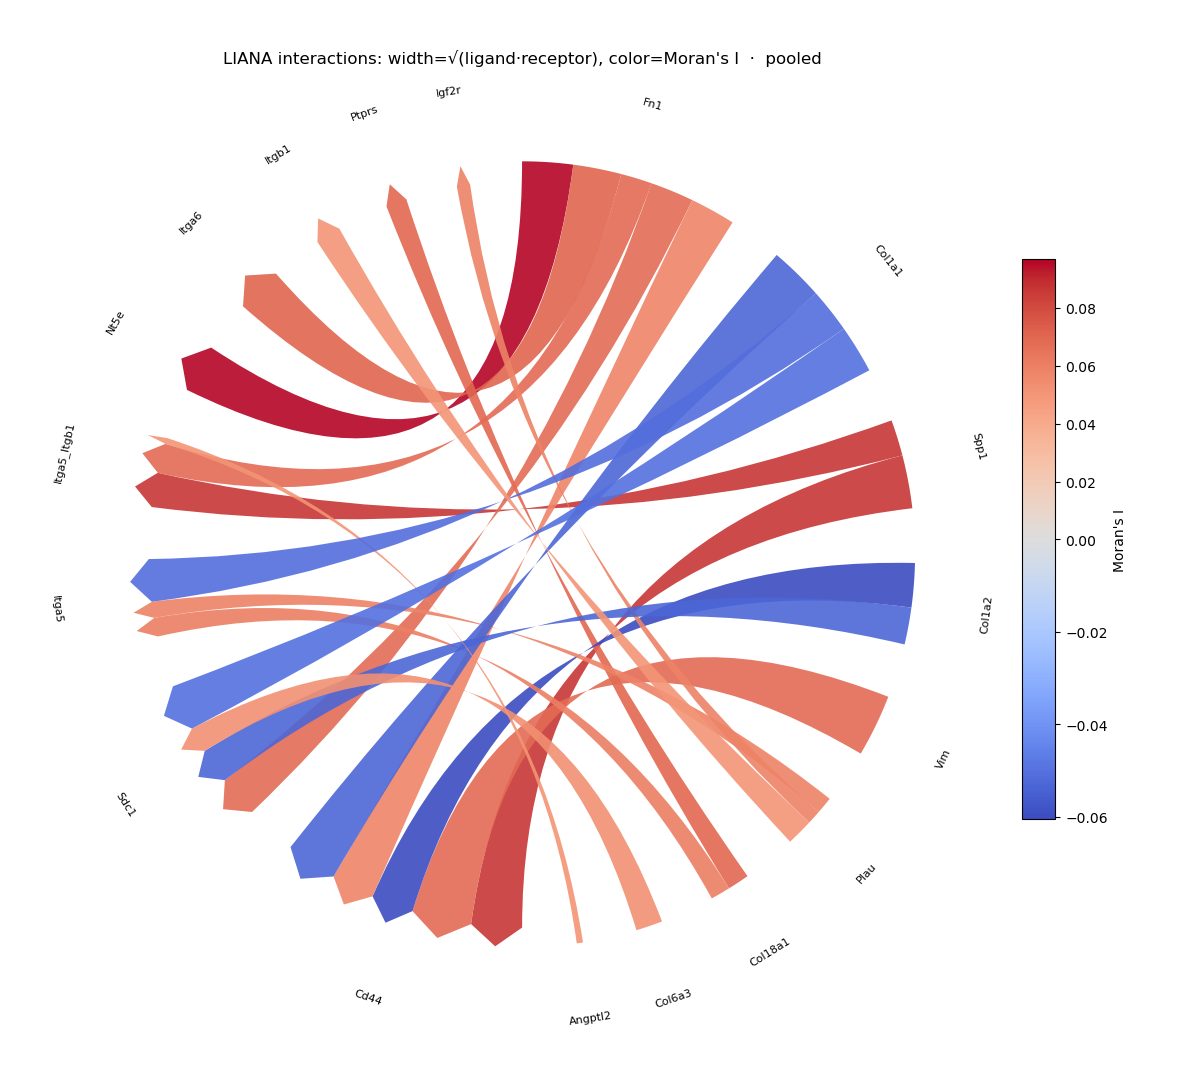

In [60]:
fig = circos.plotfig()
fig.set_size_inches(13.5, 10.0)

# circle centered with room at right for the bar
circos.ax.set_position([0.06, 0.10, 0.78, 0.80])

fig.suptitle(TITLE + (f"  ·  condition={SELECT_COND}" if SELECT_COND else "  ·  pooled"),
             fontsize=12, y=0.99)

sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cax = fig.add_axes([0.87, 0.22, 0.025, 0.56])    # slim vertical bar on right
cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
cbar.set_label("Moran's I", fontsize=10)

# base = OUT_DIR / f"circos_liana_top{TOP_N}_morans_color_{cond_tag}"
# fig.savefig(base.with_suffix(".png"), dpi=300)
# fig.savefig(base.with_suffix(".pdf"), dpi=300)
# base
